# 📊 Premier League xPTS Prediction Project

In [3]:
from google.colab import files
uploaded = files.upload()

Saving MainData.xlsx to MainData.xlsx


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

 Load and Preview the Dataset

In [5]:
file_path = 'MainData.xlsx'
df = pd.read_excel(file_path)
df.head()

,Position,Name,PM,W,D,L,GF,GA,GD,CLS,...,Xg Conceded,Xg GD,Saves per Match,Big Chances Created,Big Chances Missed,Red Cards,Home W,Away W,Home L,xPTS
0,1,Man City,38,27,5,6,83,32,NaN,19,...,31.0,NaN,1.8,79,59,2,13,14,4,83.38
1,2,Man United,38,21,11,6,73,44,NaN,13,...,42.0,NaN,2.6,68,51,1,9,12,6,65.64
2,3,Liverpool,38,20,9,9,68,42,NaN,12,...,43.6,NaN,2.6,82,68,0,10,10,6,68.80
3,4,Chelsea,38,19,10,9,58,36,NaN,18,...,30.4,NaN,1.9,62,56,3,9,10,4,77.41
4,5,Leicester City,38,20,6,12,68,50,NaN,11,...,46.7,NaN,2.3,53,45,0,9,11,9,59.75


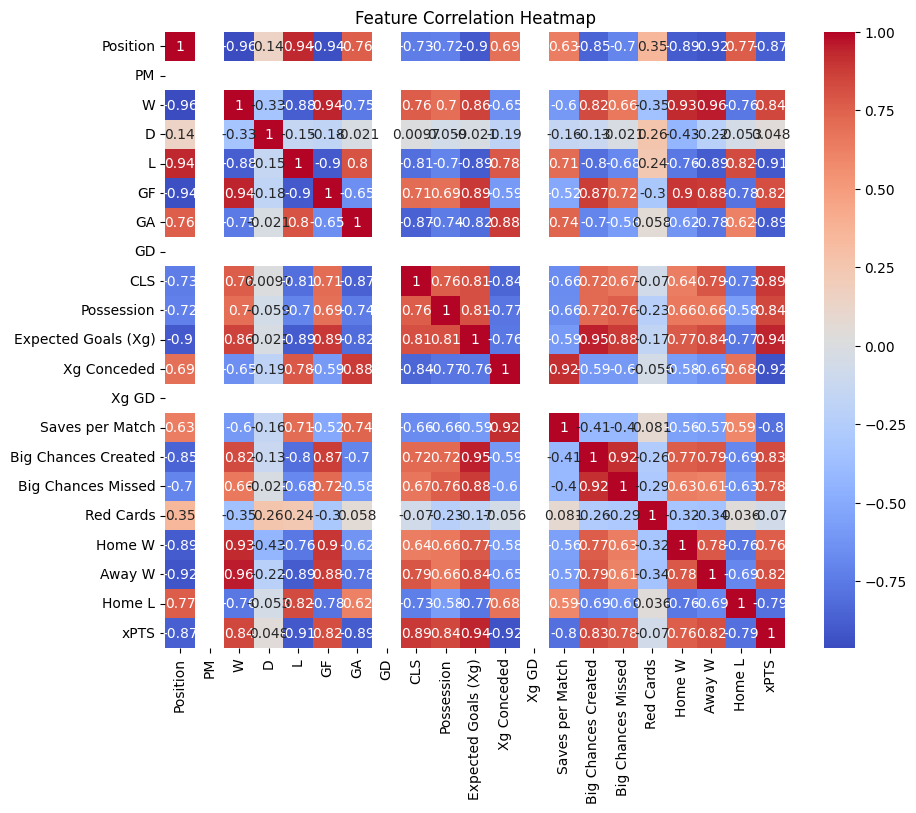

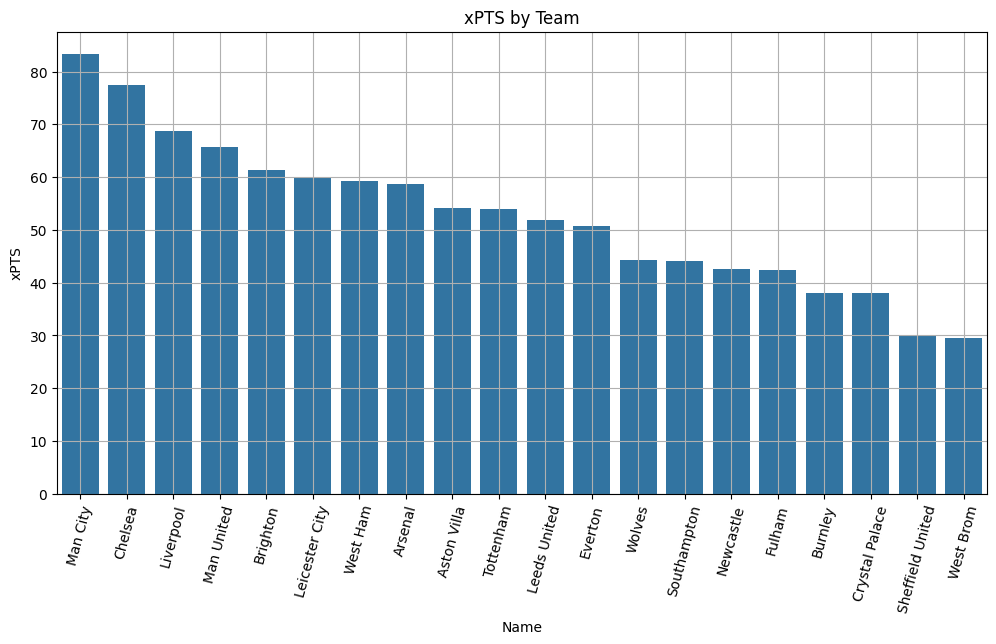

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(y='xPTS', x='Name', data=df.sort_values('xPTS', ascending=False))
plt.xticks(rotation=75)
plt.title('xPTS by Team')
plt.grid(True)
plt.show()

## Feature Engineering

In [7]:
df['GD'] = df['GF'] - df['GA']
df['Xg GD'] = df['Expected Goals (Xg)'] - df['Xg Conceded']
df['GF_minus_Xg'] = df['GF'] - df['Expected Goals (Xg)']
df['GA_minus_Xa'] = df['GA'] - df['Xg Conceded']
df.dropna(subset=['xPTS'], inplace=True)

features = [
    'GF', 'GA', 'Expected Goals (Xg)', 'Xg Conceded', 'GD', 'Xg GD',
    'Big Chances Created', 'Big Chances Missed', 'Red Cards',
    'GF_minus_Xg', 'GA_minus_Xa', 'Possession', 'Saves per Match'
]
X = df[features]
y = df['xPTS']

# Random Forest Regressor

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

## Evaluate the Model

In [9]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor


y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

Model Evaluation
MAE: 5.02
RMSE: 7.61
R2 Score: 0.73


##  Predict xPTS and Plot Results

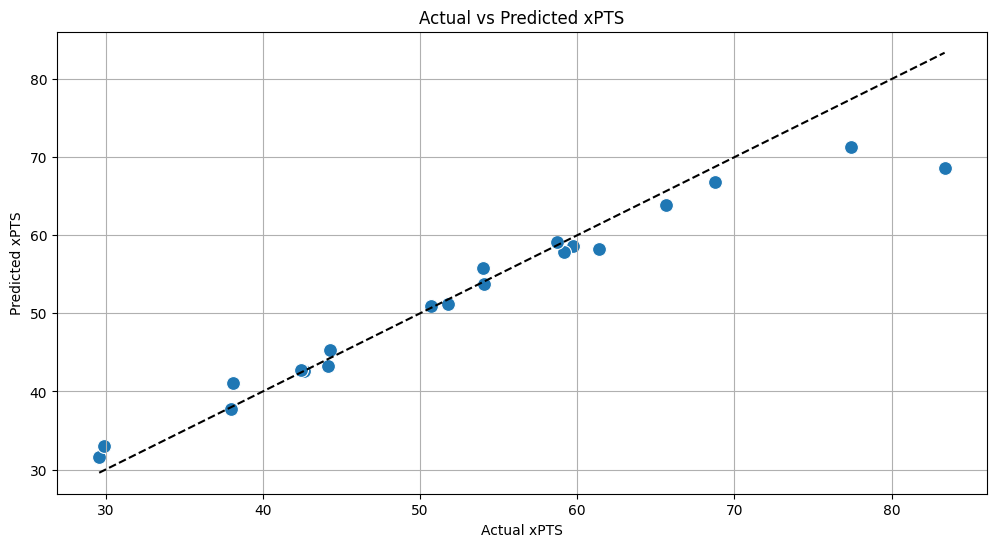

In [10]:
df['Predicted xPTS'] = model.predict(X)

plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='xPTS', y='Predicted xPTS', s=100)
plt.plot([df['xPTS'].min(), df['xPTS'].max()], [df['xPTS'].min(), df['xPTS'].max()], 'k--')
plt.title('Actual vs Predicted xPTS')
plt.xlabel('Actual xPTS')
plt.ylabel('Predicted xPTS')
plt.grid(True)
plt.show()

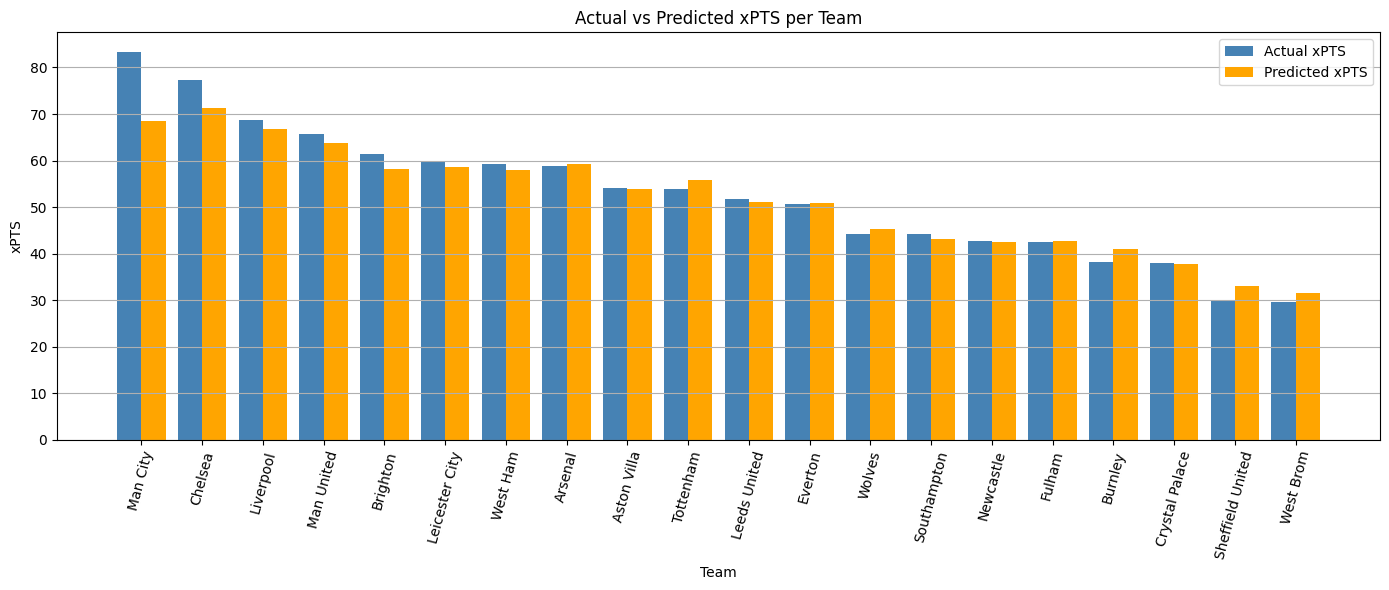

In [11]:
# Sort teams by actual xPTS
df_sorted = df.sort_values("xPTS", ascending=False)

index = np.arange(len(df_sorted))
bar_width = 0.4

plt.figure(figsize=(14, 6))
plt.bar(index, df_sorted["xPTS"], bar_width, label='Actual xPTS', color='steelblue')
plt.bar(index + bar_width, df_sorted["Predicted xPTS"], bar_width, label='Predicted xPTS', color='orange')

# Add team names to x-axis
plt.xticks(index + bar_width / 2, df_sorted["Name"], rotation=75)
plt.xlabel("Team")
plt.ylabel("xPTS")
plt.title("Actual vs Predicted xPTS per Team")
plt.legend()
plt.tight_layout()
plt.grid(axis='y')
plt.show()




## Feature Importance

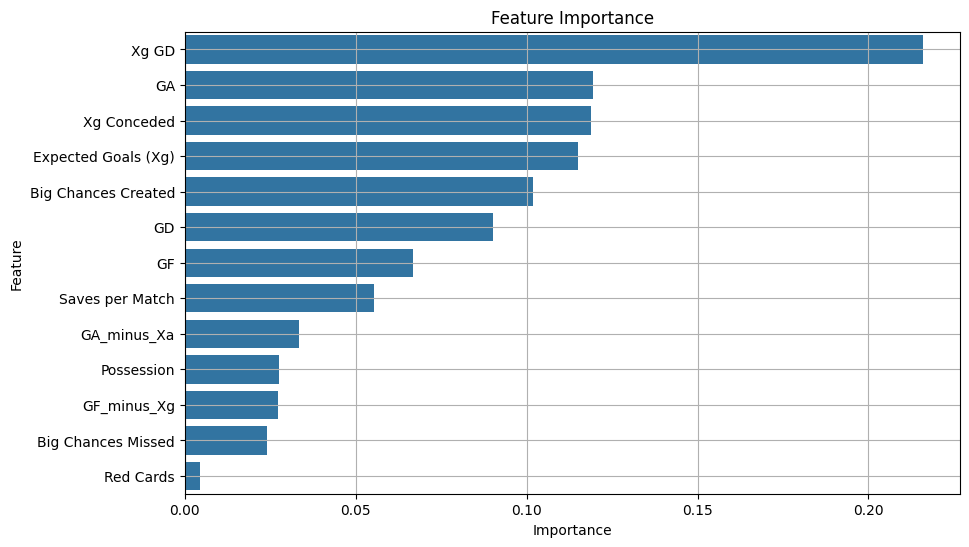

In [12]:
importances = model.feature_importances_
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance')
plt.grid(True)
plt.show()

##  Predict xPTS from Custom Input

In [15]:
def predict_custom():
    print("\n--- Predict xPTS for Custom Team Stats ---")
    custom_input = {
        "GF": float(input("Goals For (GF): ")),
        "GA": float(input("Goals Against (GA): ")),
        "Expected Goals (Xg)": float(input("Expected Goals (xG): ")),
        "Xg Conceded": float(input("xG Conceded: ")),
        "Big Chances Created": float(input("Big Chances Created: ")),
        "Big Chances Missed": float(input("Big Chances Missed: ")),
        "Red Cards": float(input("Red Cards: ")),
        "Possession": float(input("Possession %: ")),
        "Saves per Match": float(input("Saves per Match: "))
    }
    custom_input['GD'] = custom_input['GF'] - custom_input['GA']
    custom_input['Xg GD'] = custom_input['Expected Goals (Xg)'] - custom_input['Xg Conceded']
    custom_input['GF_minus_Xg'] = custom_input['GF'] - custom_input['Expected Goals (Xg)']
    custom_input['GA_minus_Xa'] = custom_input['GA'] - custom_input['Xg Conceded']

    input_df = pd.DataFrame([custom_input])[features]
    predicted = model.predict(input_df)[0]
    print(f"\n Predicted xPTS: {predicted:.2f}")

predict_custom()


--- Predict xPTS for Custom Team Stats ---
Goals For (GF): 2
Goals Against (GA): 1
Expected Goals (xG): 4
xG Conceded: 3
Big Chances Created: 8
Big Chances Missed: 2
Red Cards: 0
Possession %: 78
Saves per Match: 6

 Predicted xPTS: 52.04
